<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie NumPy
import numpy as np

In [3]:
#Importation de la librairie Matplotlib
import matplotlib.pyplot as plt

In [4]:
#Importation de la librairie Seaborn
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#Importation du fichier population.csv
population = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Projet/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Projet/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Projet/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Projet/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [7]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s) ainsi que {} colonne(s).".format(population.shape[0],population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s) ainsi que 3 colonne(s).


In [8]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)\n".format(population.columns.size))
#La nature des données dans chacune des colonnes
print("La colonne {} est de type {}.".format(population.columns[0],population[population.columns[0]].dtypes))
print("La colonne {} est de type {}.".format(population.columns[1],population[population.columns[1]].dtypes))
print("La colonne {} est de type {}.\n".format(population.columns[2],population[population.columns[2]].dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("La colonne {} comporte {} éléments.".format(population.columns[0],population[population.columns[0]].count()))
print("La colonne {} comporte {} éléments.".format(population.columns[1],population[population.columns[1]].count()))
print("La colonne {} comporte {} éléments.".format(population.columns[2],population[population.columns[2]].count()))

Le tableau comporte 3 colonne(s)

La colonne Zone est de type object.
La colonne Année est de type int64.
La colonne Valeur est de type float64.

La colonne Zone comporte 1416 éléments.
La colonne Année comporte 1416 éléments.
La colonne Valeur comporte 1416 éléments.


In [9]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [10]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur']=population['Valeur']*1_000

In [11]:
#changement du nom de la colonne Valeur par Population
population=population.rename(columns={'Valeur':'Population'})

In [12]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [13]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s) ainsi que {} colonne(s).".format(dispo_alimentaire.shape[0],dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s) ainsi que 18 colonne(s).


In [14]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s).".format(dispo_alimentaire.columns.size))

Le tableau comporte 18 colonne(s).


In [15]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [16]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire=dispo_alimentaire.fillna(0)

In [17]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire[dispo_alimentaire.columns[9:18]]=dispo_alimentaire[dispo_alimentaire.columns[9:18]]*1_000_000
dispo_alimentaire[dispo_alimentaire.columns[3:5]]=dispo_alimentaire[dispo_alimentaire.columns[3:5]]*1_000_000

In [18]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [19]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s) ainsi que {} colonne(s).".format(aide_alimentaire.shape[0],aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s) ainsi que 4 colonne(s).


In [20]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s).".format(aide_alimentaire.columns.size))

Le tableau comporte 4 colonne(s).


In [21]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [22]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire=aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})

In [23]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur']=aide_alimentaire['Valeur']*1_000

In [24]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [25]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s) ainsi que {} colonne(s).".format(sous_nutrition.shape[0],sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s) ainsi que 3 colonne(s).


In [26]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s).".format(sous_nutrition.columns.size))

Le tableau comporte 3 colonne(s).


In [27]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [28]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur']= pd.to_numeric(sous_nutrition['Valeur'],errors='coerce')

In [29]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur']=sous_nutrition['Valeur'].fillna(0)

In [30]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition=sous_nutrition.rename(columns={'Valeur':'Sous_nutrition'})

In [31]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['Sous_nutrition']=sous_nutrition['Sous_nutrition']*1_000_000

In [32]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [33]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
remplacements = {'2012-2014':'2013','2013-2015':'2014','2014-2016':'2015','2015-2017':'2016','2016-2018':'2017','2017-2019':'2018'}
sous_nutrition['Année']=sous_nutrition['Année'].replace(remplacements).astype(int)
population_sous_nutrition=pd.merge(population,sous_nutrition,on=['Zone','Année'],how='inner')
population_sous_nutrition_2017=population_sous_nutrition.loc[population_sous_nutrition['Année']==2017,:]

In [34]:
#Affichage du dataset
display(population_sous_nutrition_2017)

,Zone,Année,Population,Sous_nutrition
4,Afghanistan,2017,36296113.0,10500000.0
10,Afrique du Sud,2017,57009756.0,3100000.0
16,Albanie,2017,2884169.0,100000.0
22,Algérie,2017,41389189.0,1300000.0
28,Allemagne,2017,82658409.0,0.0
...,...,...,...,...
1192,Venezuela (République bolivarienne du),2017,29402484.0,8000000.0
1198,Viet Nam,2017,94600648.0,6500000.0
1204,Yémen,2017,27834819.0,0.0
1210,Zambie,2017,16853599.0,0.0


In [35]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
total_population_2017=population_sous_nutrition_2017['Population'].sum()
total_sous_nutrition_2017=population_sous_nutrition_2017['Sous_nutrition'].sum()
proportion_sous_nutrition_2017=round((total_sous_nutrition_2017/total_population_2017)*100)
print('Nous comptions environ {} millions de personnes en état de sous nutrition en 2017, soit {}% de la population mondiale.'.format(round(total_sous_nutrition_2017/1_000_000),proportion_sous_nutrition_2017))

Nous comptions environ 536 millions de personnes en état de sous nutrition en 2017, soit 7% de la population mondiale.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [36]:
#Combien mange en moyenne un être humain ? Source => Organisation des Nations unies pour l'alimentation et l'agriculture
kcal_pers_jour=2940
print('Un être humain mange pour environ {} kcal par jour (chiffres de 2015).'.format(kcal_pers_jour))

Un être humain mange pour environ 2940 kcal par jour (chiffres de 2015).


In [37]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alimentaire_vs_population=pd.merge(dispo_alimentaire,population_sous_nutrition_2017,on='Zone',how='left')

In [38]:
#Affichage du nouveau dataframe
dispo_alimentaire_vs_population

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population,Sous_nutrition
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0,10500000.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0,10500000.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,10500000.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,10500000.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0,10500000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,...,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,2017.0,636039.0,0.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,636039.0,0.0


In [39]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_alimentaire_vs_population['dispo_kcal']=dispo_alimentaire_vs_population['Disponibilité alimentaire (Kcal/personne/jour)']*dispo_alimentaire_vs_population['Population']
total_kcal_jour=dispo_alimentaire_vs_population['dispo_kcal'].sum()
print('Il y avait environ {} milliards de kcal disponibles par jour dans le monde en 2017.'.format(round(total_kcal_jour/1_000_000_000)))

Il y avait environ 20919 milliards de kcal disponibles par jour dans le monde en 2017.


In [40]:
#Calcul du nombre d'humains pouvant être nourris
nourrir_max=total_kcal_jour/kcal_pers_jour
print('{} milliards d\'humains pouvaient être nourris soit {}% de la population terrestre en 2017.'.format(round(nourrir_max/1_000_000_000,2),round(((nourrir_max/1_000_000_000)/(total_population_2017/1_000_000_000))*100,2)))

7.12 milliards d'humains pouvaient être nourris soit 94.32% de la population terrestre en 2017.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [41]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_vegetaux=dispo_alimentaire_vs_population.loc[dispo_alimentaire_vs_population['Origine']=='vegetale']

In [42]:
#Calcul du nombre de kcal disponible pour les végétaux
dispo_kcal_vegetaux=dispo_vegetaux['dispo_kcal'].sum()
print('Il y avait environ {} milliards de kcal disponibles par jour dans le monde en 2017.'.format(round(dispo_kcal_vegetaux/1_000_000_000)))

Il y avait environ 17261 milliards de kcal disponibles par jour dans le monde en 2017.


In [43]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nourrir_max_vegetaux=dispo_kcal_vegetaux/kcal_pers_jour
print('{} milliards d\'humains pouvaient être nourris avec les végétaux soit {}% de la population terrestre en 2017.'.format(round(nourrir_max_vegetaux/1_000_000_000,2),round(((nourrir_max_vegetaux/1_000_000_000)/(total_population_2017/1_000_000_000))*100,2)))

5.87 milliards d'humains pouvaient être nourris avec les végétaux soit 77.83% de la population terrestre en 2017.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [44]:
#Calcul de la disponibilité totale
dispo_interieure=dispo_alimentaire_vs_population['Disponibilité intérieure'].sum()
print('La disponibilité intérieure cumulée de tous les pays est de {} millions de tonnes de nourriture.'.format(round(dispo_interieure/1_000_000_000)))

La disponibilité intérieure cumulée de tous les pays est de 9849 millions de tonnes de nourriture.


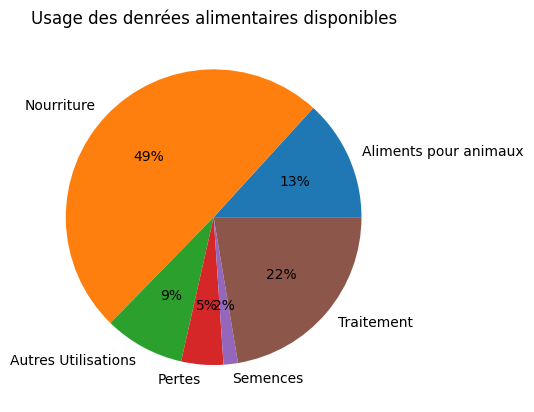

In [45]:
#Usage de la dispo intérieure
dataviz_dispo_interieure=dispo_alimentaire_vs_population.loc[:,["Aliments pour animaux","Nourriture","Autres Utilisations", "Pertes", "Semences", "Traitement"]].sum().reset_index()
dataviz_dispo_interieure.columns=["Usage","Poids"]
plt.pie(x=dataviz_dispo_interieure["Poids"], labels=dataviz_dispo_interieure["Usage"],autopct='%.f%%')
plt.title("Usage des denrées alimentaires disponibles")
plt.show()

In [46]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
for index, row in dispo_alimentaire_vs_population.iterrows():
    message = (
        f"Dans la zone du {row['Zone']}, "
        f"pour les produits de type {row['Produit']} "
        f"d'origine {row['Origine']}, "
        f"il y a {row['Disponibilité intérieure']} kg disponibles, "
        f"dont {row['Aliments pour animaux']} kg d'aliments pour animaux, "
        f"{row['Pertes']} de pertes et {row['Nourriture']} de nourriture."
    )
    print(message)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Dans la zone du Pakistan, pour les produits de type Viande de Volailles d'origine animale, il y a 912000000.0 kg disponibles, dont 0.0 kg d'aliments pour animaux, 0.0 de pertes et 912000000.0 de nourriture.
Dans la zone du Pakistan, pour les produits de type Viande, Autre d'origine animale, il y a 23000000.0 kg disponibles, dont 0.0 kg d'aliments pour animaux, 0.0 de pertes et 23000000.0 de nourriture.
Dans la zone du Pakistan, pour les produits de type Vin d'origine vegetale, il y a 0.0 kg disponibles, dont 0.0 kg d'aliments pour animaux, 0.0 de pertes et 0.0 de nourriture.
Dans la zone du Pakistan, pour les produits de type Épices, Autres d'origine vegetale, il y a 124000000.0 kg disponibles, dont 0.0 kg d'aliments pour animaux, 0.0 de pertes et 124000000.0 de nourriture.
Dans la zone du Panama, pour les produits de type Abats Comestible d'origine animale, il y a 14000000.0 kg disponibles, dont 0.0 kg d'ali

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [47]:
#Lister les produits d'origine végétales
dispo_alimentaire_vs_population.loc[dispo_alimentaire_vs_population["Origine"]=="vegetale","Produit"].unique()

array(['Agrumes, Autres', 'Aliments pour enfants', 'Ananas', 'Bananes',
       'Bière', 'Blé', 'Boissons Alcooliques', 'Café',
       'Coco (Incl Coprah)', 'Céréales, Autres', 'Dattes',
       'Edulcorants Autres', 'Feve de Cacao', 'Fruits, Autres',
       'Graines de coton', 'Graines de tournesol',
       'Huil Plantes Oleif Autr', 'Huile Graines de Coton',
       "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde',
       'Huile de Palme', 'Huile de Soja', 'Huile de Sésame',
       'Huile de Tournesol', 'Légumes, Autres', 'Légumineuses Autres',
       'Maïs', 'Miel', 'Millet', 'Miscellanees', 'Noix', 'Olives',
       'Oranges, Mandarines', 'Orge', 'Plantes Oleiferes, Autre',
       'Poivre', 'Pommes', 'Pommes de Terre', 'Raisin',
       'Riz (Eq Blanchi)', 'Sucre Eq Brut', 'Sucre, betterave',
       'Sucre, canne', 'Sésame', 'Thé', 'Tomates', 'Vin',
       'Épices, Autres', 'Alcool, non Comestible',
       'Arachides Decortiquees', 'Avoine', 'Bananes plantains',
       'Bo

In [48]:
#Création d'une liste avec toutes les variables
cereales=['Blé', 'Céréales, Autres', 'Maïs', 'Millet', 'Orge', 'Riz (Eq Blanchi)', 'Avoine', 'Seigle', 'Sorgho']

In [49]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_cereales=dispo_alimentaire_vs_population.loc[dispo_alimentaire_vs_population['Produit'].isin(cereales)]

In [50]:
#Affichage de la proportion d'alimentation animale
proportion_alim_animale=round((dispo_cereales['Aliments pour animaux'].sum()/dispo_cereales['Disponibilité intérieure'].sum())*100)
print("{}% de la disponibilité intérieure globale est attribuée à l'alimentation animale".format(proportion_alim_animale))

36% de la disponibilité intérieure globale est attribuée à l'alimentation animale


In [51]:
#Affichage de la proportion d'alimentation humaine
proportion_nourriture=round((dispo_cereales['Nourriture'].sum()/dispo_cereales['Disponibilité intérieure'].sum())*100)
print("{}% de la disponibilité intérieure globale est attribuée à l'alimentation humaine.".format(proportion_nourriture))

43% de la disponibilité intérieure globale est attribuée à l'alimentation humaine.


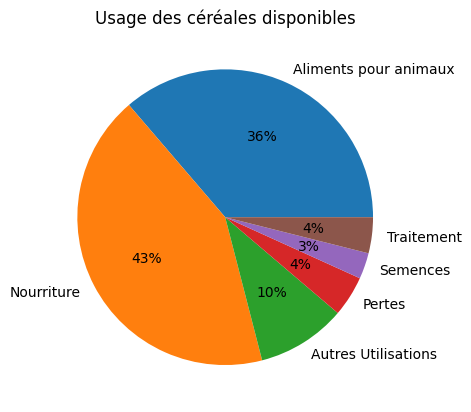

In [52]:
#Affichage des différents usages des céréales disponibles
dataviz_dispo_cereales=dispo_cereales.loc[:,["Aliments pour animaux","Nourriture","Autres Utilisations", "Pertes", "Semences", "Traitement"]].sum()
dataviz_dispo_cereales=dataviz_dispo_cereales.reset_index()
dataviz_dispo_cereales.columns=["Usage","Poids"]
plt.pie(x=dataviz_dispo_cereales["Poids"], labels=dataviz_dispo_cereales["Usage"],autopct='%.f%%')
plt.title("Usage des céréales disponibles")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [53]:
#Création de la colonne proportion par pays
dispo_alimentaire_vs_population['proportion_pays']=round(dispo_alimentaire_vs_population['Sous_nutrition']/dispo_alimentaire_vs_population['Population']*100,2)

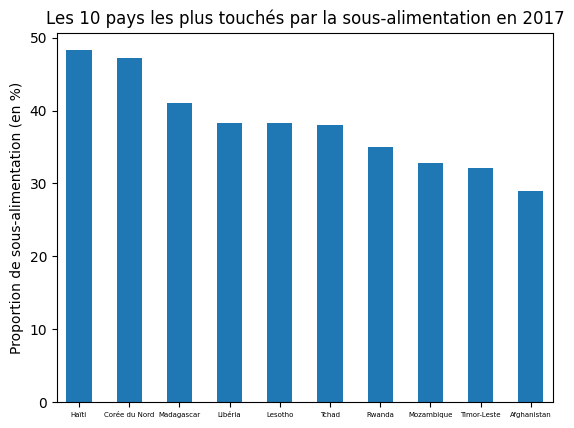

In [54]:
#affichage après trie des 10 pires pays
dispo_alimentaire_2017=dispo_alimentaire_vs_population[["Zone","proportion_pays"]].loc[dispo_alimentaire_vs_population["Année"]==2017].groupby("Zone", as_index=False).first()
dispo_alimentaire_2017.loc[dispo_alimentaire_2017["Zone"]=="République populaire démocratique de Corée","Zone"]="Corée du Nord"
dispo_alimentaire_2017=dispo_alimentaire_2017.sort_values(by='proportion_pays',ascending=False)
top_10_pires_pays=dispo_alimentaire_2017.head(10)
plt.bar(top_10_pires_pays['Zone'],top_10_pires_pays['proportion_pays'],width=0.5)
plt.title("Les 10 pays les plus touchés par la sous-alimentation en 2017")
plt.ylabel("Proportion de sous-alimentation (en %)")
plt.xticks(rotation=0, ha='center', fontsize=5)
plt.margins(x=0.0005)
plt.margins(x=0.02)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [55]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_pays=aide_alimentaire.groupby("Zone", as_index=False)["Valeur"].sum()

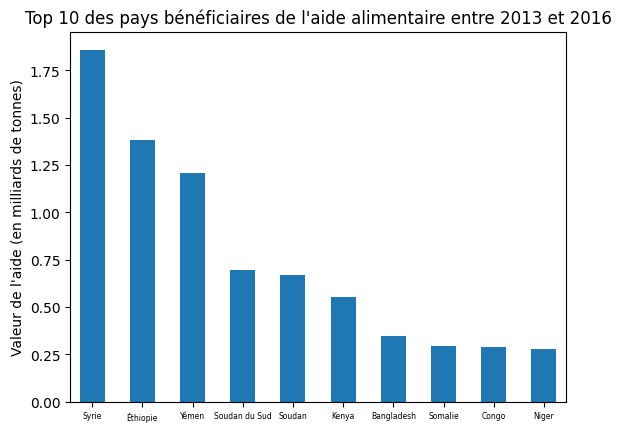

In [56]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_pays['Valeur']=aide_alimentaire_pays['Valeur']/1_000_000_000
aide_alimentaire_pays.loc[aide_alimentaire_pays["Zone"]=="République arabe syrienne","Zone"]="Syrie"
aide_alimentaire_pays.loc[aide_alimentaire_pays["Zone"]=="République démocratique du Congo","Zone"]="Congo"
aide_alimentaire_pays=aide_alimentaire_pays.sort_values(by='Valeur',ascending=False)
top_10_aide=aide_alimentaire_pays.head(10)
plt.bar(top_10_aide['Zone'],top_10_aide['Valeur'],width=0.5)
plt.title("Top 10 des pays bénéficiaires de l'aide alimentaire entre 2013 et 2016")
plt.ylabel("Valeur de l'aide (en milliards de tonnes)")
plt.xticks(rotation=0, ha='center', fontsize=5.5)
plt.margins(x=0.0005)
plt.margins(x=0.02)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [57]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aide_alimentaire_annee=aide_alimentaire[["Zone","Année","Valeur"]].groupby(["Zone","Année"],as_index=False)["Valeur"].sum()
aide_alimentaire_annee['Valeur']=aide_alimentaire_annee['Valeur']/1_000_000

In [58]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top_5=aide_alimentaire_annee.sort_values(by="Valeur",ascending=False)["Zone"].unique()[:5].tolist()

In [59]:
#On filtre sur le dataframe avec notre liste
aide_alimentaire_top5=aide_alimentaire_annee.loc[aide_alimentaire_annee["Zone"].isin(top_5)]
aide_alimentaire_top5.loc[aide_alimentaire_top5["Zone"]=="République arabe syrienne","Zone"]="Syrie"

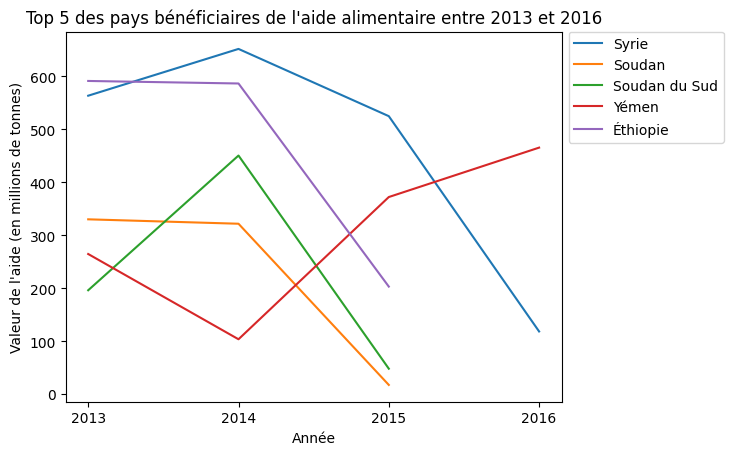

In [60]:
# Affichage des pays avec l'aide alimentaire par année
sns.lineplot(data=aide_alimentaire_top5, x='Année', y='Valeur', hue='Zone')
plt.xticks(sorted(aide_alimentaire_top5["Année"].unique()))
plt.legend(bbox_to_anchor=(1, 1.02))
plt.title("Top 5 des pays bénéficiaires de l'aide alimentaire entre 2013 et 2016")
plt.ylabel("Valeur de l'aide (en millions de tonnes)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [61]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire_pays=dispo_alimentaire[["Zone","Disponibilité alimentaire (Kcal/personne/jour)"]].groupby("Zone",as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"].sum()

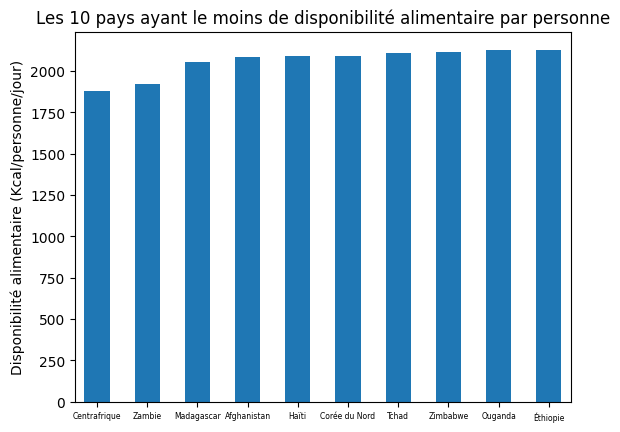

In [62]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
dispo_alimentaire_pays=dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)")
dispo_alimentaire_pays.loc[dispo_alimentaire_pays["Zone"]=="République centrafricaine","Zone"]="Centrafrique"
dispo_alimentaire_pays.loc[dispo_alimentaire_pays["Zone"]=="République populaire démocratique de Corée","Zone"]="Corée du Nord"
top_10_dispo_moins=dispo_alimentaire_pays.head(10)
plt.bar(top_10_dispo_moins['Zone'],top_10_dispo_moins['Disponibilité alimentaire (Kcal/personne/jour)'],width=0.5)
plt.title("Les 10 pays ayant le moins de disponibilité alimentaire par personne")
plt.ylabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.xticks(rotation=0, ha='center', fontsize=5.5)
plt.margins(x=0.0005)
plt.margins(x=0.02)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

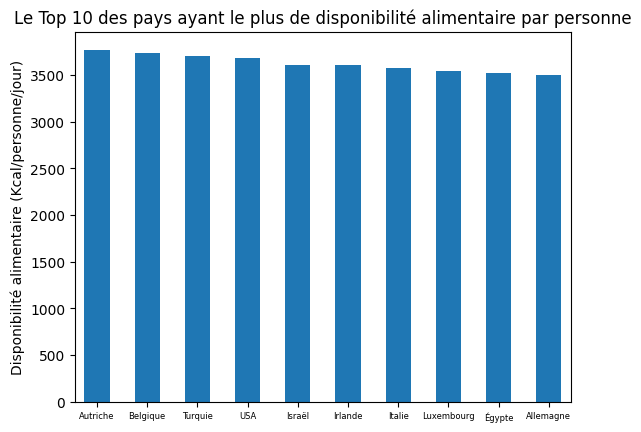

In [63]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
dispo_alimentaire_pays=dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False)
dispo_alimentaire_pays.loc[dispo_alimentaire_pays["Zone"]=="États-Unis d'Amérique","Zone"]="USA"
top_10_dispo_plus=dispo_alimentaire_pays.head(10)
plt.bar(top_10_dispo_plus['Zone'],top_10_dispo_plus['Disponibilité alimentaire (Kcal/personne/jour)'],width=0.5)
plt.xticks(rotation=90)
plt.title("Le Top 10 des pays ayant le plus de disponibilité alimentaire par personne")
plt.ylabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.xticks(rotation=0, ha='center', fontsize=6)
plt.margins(x=0.0005)
plt.margins(x=0.02)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [64]:
#création d'un dataframe avec uniquement la Thaïlande
dispo_alimentaire_thailande=dispo_alimentaire_vs_population.loc[dispo_alimentaire["Zone"]=="Thaïlande"]

In [65]:
#Calcul de la sous nutrition en Thaïlande
total_population_thai=dispo_alimentaire_thailande["Population"].unique()[0]
total_sous_nutrition_thai=dispo_alimentaire_thailande["Sous_nutrition"].unique()[0]
proportion_sous_nutrition_thai=round((total_sous_nutrition_thai/total_population_thai)*100)
print('Nous comptions environ {} millions de personnes en état de sous nutrition en 2017 en Thailande, soit environ {}% de la population thailandaise.'.format(round(total_sous_nutrition_thai/1_000_000),proportion_sous_nutrition_thai))

Nous comptions environ 6 millions de personnes en état de sous nutrition en 2017 en Thailande, soit environ 9% de la population thailandaise.


In [66]:
# On calcule la proportion exportée en fonction de la production
dispo_manioc_thai=dispo_alimentaire_thailande.loc[dispo_alimentaire_thailande["Produit"]=="Manioc"]
exp_manioc_thai=dispo_manioc_thai["Exportations - Quantité"].sum()/dispo_manioc_thai["Production"].sum()
print("La Thaïlande exporte environ {}% du manioc qu'elle produit.".format(round(exp_manioc_thai*100)))

La Thaïlande exporte environ 83% du manioc qu'elle produit.


::<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

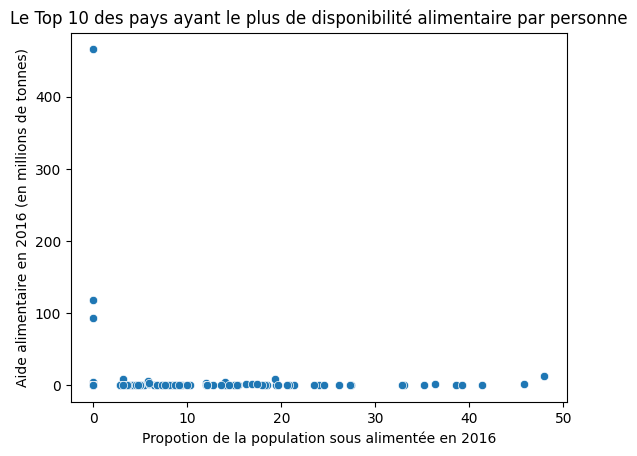

In [67]:
#ajouter en dessous toutes les analyses complémentaires
aide_alimentaire_pays_2016=aide_alimentaire.loc[aide_alimentaire["Année"]==2016].groupby("Zone", as_index=False)["Valeur"].sum()
population_sous_nutrition_2016=population_sous_nutrition.loc[population_sous_nutrition["Année"]==2016].groupby("Zone", as_index=False)[["Sous_nutrition","Population"]].sum()
population_sous_nutrition_2016["proportion_pays"]=population_sous_nutrition_2016["Sous_nutrition"]/population_sous_nutrition_2016["Population"]*100
aide_alimentaire_pays_2016['Valeur']=aide_alimentaire_pays_2016['Valeur']/1_000_000
sous_alimentation_vs_aide_alimentaire=pd.merge(population_sous_nutrition_2016,aide_alimentaire_pays_2016,on=['Zone'],how='outer').fillna(0)
sns.scatterplot(data=sous_alimentation_vs_aide_alimentaire, x='proportion_pays', y='Valeur')
plt.title("Le Top 10 des pays ayant le plus de disponibilité alimentaire par personne")
plt.xlabel("Propotion de la population sous alimentée en 2016")
plt.ylabel("Aide alimentaire en 2016 (en millions de tonnes)")
plt.show()

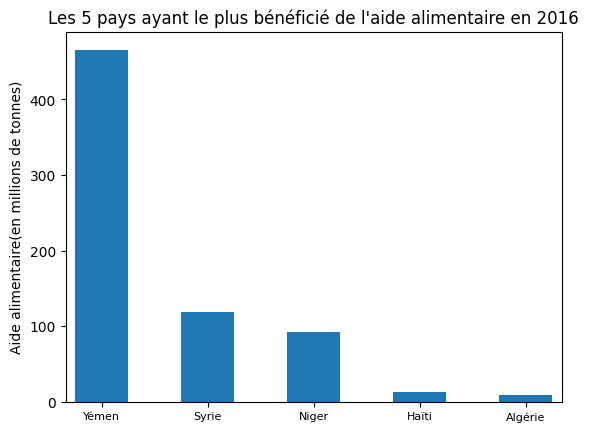


Les pays du top 3 étaient en guerre sur l'année 2016 ce qui explique la mobilisation d'autant d'aide alimentaire malgré leur proportion de sous alimentation de la population proche de 0.
Par ailleurs, cette dernière information peut être manquante à cause de l'instabilité géopolitique de ces pays.


In [68]:
top_5_aide_2016=sous_alimentation_vs_aide_alimentaire.sort_values(by='Valeur',ascending=False).head(5)
top_5_aide_2016.loc[top_5_aide_2016["Zone"]=="République arabe syrienne","Zone"]="Syrie"
plt.bar(top_5_aide_2016['Zone'],top_5_aide_2016['Valeur'],width=0.5)
plt.xticks(rotation=90)
plt.title("Les 5 pays ayant le plus bénéficié de l'aide alimentaire en 2016")
plt.ylabel("Aide alimentaire(en millions de tonnes)")
plt.xticks(rotation=0, ha='center', fontsize=8)
plt.margins(x=0.0005)
plt.margins(x=0.02)
plt.show()
print("\nLes pays du top 3 étaient en guerre sur l'année 2016 ce qui explique la mobilisation d'autant d'aide alimentaire malgré leur proportion de sous alimentation de la population proche de 0.\nPar ailleurs, cette dernière information peut être manquante à cause de l'instabilité géopolitique de ces pays.")

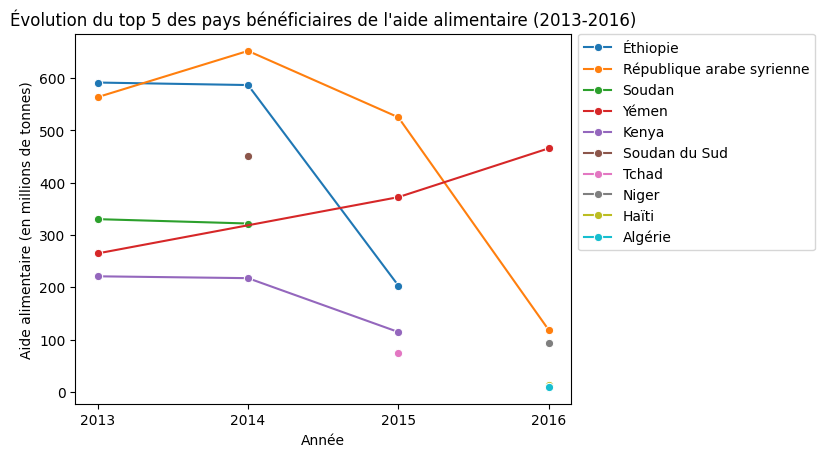

In [69]:
#2013
aide_alimentaire_pays_2013=aide_alimentaire.loc[aide_alimentaire["Année"]==2013].groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
population_sous_nutrition_2013=population_sous_nutrition.loc[population_sous_nutrition["Année"]==2013].groupby(["Zone", "Année"], as_index=False)[["Sous_nutrition","Population"]].sum()
population_sous_nutrition_2013["proportion_pays"]=population_sous_nutrition_2013["Sous_nutrition"]/population_sous_nutrition_2013["Population"]*100
aide_alimentaire_pays_2013['Valeur']=aide_alimentaire_pays_2013['Valeur']/1_000_000
sous_alimentation_vs_aide_alimentaire_2013=pd.merge(population_sous_nutrition_2013,aide_alimentaire_pays_2013,on=['Zone','Année'],how='outer').fillna(0)
top5_aide_2013=sous_alimentation_vs_aide_alimentaire_2013.sort_values(by='Valeur',ascending=False).head(5)

#2014
aide_alimentaire_pays_2014=aide_alimentaire.loc[aide_alimentaire["Année"]==2014].groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
population_sous_nutrition_2014=population_sous_nutrition.loc[population_sous_nutrition["Année"]==2014].groupby(["Zone", "Année"], as_index=False)[["Sous_nutrition","Population"]].sum()
population_sous_nutrition_2014["proportion_pays"]=population_sous_nutrition_2014["Sous_nutrition"]/population_sous_nutrition_2014["Population"]*100
aide_alimentaire_pays_2014['Valeur']=aide_alimentaire_pays_2014['Valeur']/1_000_000
sous_alimentation_vs_aide_alimentaire_2014=pd.merge(population_sous_nutrition_2014,aide_alimentaire_pays_2014,on=['Zone','Année'],how='outer').fillna(0)
top5_aide_2014=sous_alimentation_vs_aide_alimentaire_2014.sort_values(by='Valeur',ascending=False).head(5)

#2015
aide_alimentaire_pays_2015=aide_alimentaire.loc[aide_alimentaire["Année"]==2015].groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
population_sous_nutrition_2015=population_sous_nutrition.loc[population_sous_nutrition["Année"]==2015].groupby(["Zone", "Année"], as_index=False)[["Sous_nutrition","Population"]].sum()
population_sous_nutrition_2015["proportion_pays"]=population_sous_nutrition_2015["Sous_nutrition"]/population_sous_nutrition_2015["Population"]*100
aide_alimentaire_pays_2015['Valeur']=aide_alimentaire_pays_2015['Valeur']/1_000_000
sous_alimentation_vs_aide_alimentaire_2015=pd.merge(population_sous_nutrition_2015,aide_alimentaire_pays_2015,on=['Zone','Année'],how='outer').fillna(0)
top5_aide_2015=sous_alimentation_vs_aide_alimentaire_2015.sort_values(by='Valeur',ascending=False).head(5)

#2016
aide_alimentaire_pays_2016=aide_alimentaire.loc[aide_alimentaire["Année"]==2016].groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
population_sous_nutrition_2016=population_sous_nutrition.loc[population_sous_nutrition["Année"]==2016].groupby(["Zone", "Année"], as_index=False)[["Sous_nutrition","Population"]].sum()
population_sous_nutrition_2016["proportion_pays"]=population_sous_nutrition_2016["Sous_nutrition"]/population_sous_nutrition_2016["Population"]*100
aide_alimentaire_pays_2016['Valeur']=aide_alimentaire_pays_2016['Valeur']/1_000_000
sous_alimentation_vs_aide_alimentaire_2016=pd.merge(population_sous_nutrition_2016,aide_alimentaire_pays_2016,on=['Zone','Année'],how='outer').fillna(0)
top5_aide_2016=sous_alimentation_vs_aide_alimentaire_2016.sort_values(by='Valeur',ascending=False).head(5)

#Concaténation
top5_aide=pd.concat([top5_aide_2013,top5_aide_2014, top5_aide_2015, top5_aide_2016], ignore_index=True)

#Visuel
sns.lineplot(data=top5_aide, x='Année', y='Valeur', hue="Zone", marker="o")
plt.title("Évolution du top 5 des pays bénéficiaires de l'aide alimentaire (2013-2016)")
plt.xticks(sorted(top5_aide["Année"].unique()))
plt.legend(bbox_to_anchor=(1, 1.02))
plt.ylabel("Aide alimentaire (en millions de tonnes)")
plt.show()